<a href="https://colab.research.google.com/github/Ayodeji0001/invoice-audit/blob/main/Invoice_Pipeline_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Invoice Pipeline Audit

**Can this invoice pipeline be trusted to run without a human watching it?**

I built an automated invoice-intake pipeline (n8n + Mistral OCR) that reads emailed invoice
PDFs, extracts the key fields, checks them for defects, and decides whether each invoice can be
auto-approved or needs a human to review it.

This notebook tests that pipeline end to end and answers one question per section:

1. Is the data reliable enough to trust the results?
2. How accurate is the extraction?
3. Why did the first accuracy score look bad, and what was the real number?
4. Does duplicate detection work?
5. Does routing work?
6. Overall: can it be trusted?

**The evidence.** Two files, matched on one shared key.

| File | What it holds |
|---|---|
| `ground_truth.csv` | The answer key. Every invoice's correct values, and which defect I injected, if any. |
| `audit_trail.csv` | What the pipeline logged: the values it read, the issues it flagged, the route it chose. |

## 1 · Is the data reliable?

**Question.** Before measuring anything, does each invoice appear exactly once, and did every
invoice I sent actually make it into the logs?

In [1]:
import duckdb, pandas as pd, numpy as np, re
from datetime import datetime
import matplotlib.pyplot as plt

# one visual system, applied to every chart in this notebook
INK, MUTE, GOOD, FLAG, FAINT = "#1F2A37", "#8A94A6", "#2E7D5B", "#C4552F", "#EAECEF"
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelcolor": INK, "axes.labelsize": 10,
    "xtick.color": MUTE, "ytick.color": INK, "xtick.labelsize": 9, "ytick.labelsize": 10,
    "font.family": "DejaVu Sans",
})

db = duckdb.connect()
db.execute("CREATE VIEW audit AS SELECT * FROM read_csv_auto('audit_trail.csv', all_varchar=true)")
db.execute("CREATE VIEW truth AS SELECT * FROM read_csv_auto('ground_truth.csv', all_varchar=true)")

db.sql("""
    SELECT 'audit' AS source, count(*) AS log_rows, count(DISTINCT invoice_uid) AS invoices
    FROM audit
    UNION ALL
    SELECT 'truth', count(*), count(DISTINCT uid) FROM truth
""")

┌─────────┬──────────┬──────────┐
│ source  │ log_rows │ invoices │
│ varchar │  int64   │  int64   │
├─────────┼──────────┼──────────┤
│ audit   │      152 │      150 │
│ truth   │      150 │      150 │
└─────────┴──────────┴──────────┘

The audit log has more rows than invoices. That is worth one look before trusting anything
downstream.

In [2]:
db.sql("""
    WITH repeated AS (
        SELECT invoice_uid FROM audit
        WHERE invoice_uid <> '' GROUP BY invoice_uid HAVING count(*) > 1
    )
    SELECT a.invoice_uid, a.status, a.issues, a.processed_at
    FROM audit a JOIN repeated USING (invoice_uid)
    ORDER BY a.processed_at
""")

┌──────────────────────────────────────┬──────────────────┬───────────────────────────────────────┬──────────────────────────┐
│             invoice_uid              │      status      │                issues                 │       processed_at       │
│               varchar                │     varchar      │                varchar                │         varchar          │
├──────────────────────────────────────┼──────────────────┼───────────────────────────────────────┼──────────────────────────┤
│ 617024cd-81d7-42fb-9e32-ef876cef1b5c │ Auto-Approved    │ None                                  │ 2026-06-29T19:24:20.980Z │
│ 617024cd-81d7-42fb-9e32-ef876cef1b5c │ Pending Approval │ Duplicate invoice - already processed │ 2026-06-29T19:24:24.319Z │
└──────────────────────────────────────┴──────────────────┴───────────────────────────────────────┴──────────────────────────┘

The extra rows are not a problem. One invoice was sent twice (a seeded duplicate); the pipeline
auto-approved the first copy and flagged the second as a duplicate, so it logged twice. One other
row has no invoice ID at all: a leftover from an earlier run, dropped below.

Three cleaning rules follow from this, and everything downstream uses them:

- Drop the single no-ID row.
- For accuracy, keep the **first** log row per invoice.
- For duplicate scoring, keep **all** rows, since a duplicate only shows up on the second copy.

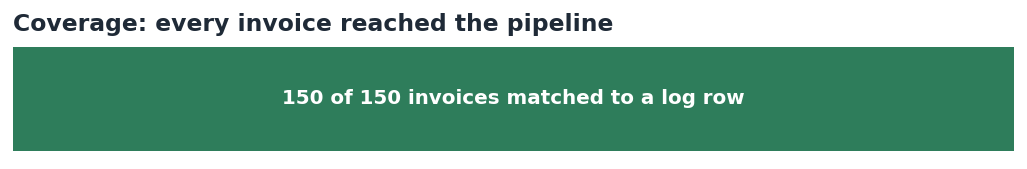

In [3]:
matched = db.sql("""
    WITH first_pass AS (
        SELECT *, row_number() OVER (PARTITION BY invoice_uid ORDER BY processed_at) AS pass_no
        FROM audit WHERE invoice_uid <> ''
    )
    SELECT
        t.uid, t.injected_error, t.expected_route,
        t.vendor_name    AS truth_vendor,  a.vendor_name    AS got_vendor,
        t.invoice_number AS truth_number,  a.invoice_number AS got_number,
        t.invoice_date   AS truth_date,    a.invoice_date   AS got_date,
        CAST(t.subtotal     AS DOUBLE) AS truth_subtotal, a.subtotal     AS got_subtotal,
        CAST(t.tax          AS DOUBLE) AS truth_tax,      a.tax          AS got_tax,
        CAST(t.total_amount AS DOUBLE) AS truth_total,    a.total_amount AS got_total,
        a.status, a.issues
    FROM truth t
    JOIN first_pass a ON a.invoice_uid = t.uid AND a.pass_no = 1
""").df()

sent = db.sql("SELECT count(*) FROM truth").fetchone()[0]
coverage = len(matched) / sent

fig, ax = plt.subplots(figsize=(8, 1.4))
ax.barh([0], [sent], color=FAINT, height=.5)
ax.barh([0], [len(matched)], color=GOOD, height=.5)
ax.text(len(matched)/2, 0, f"{len(matched)} of {sent} invoices matched to a log row",
        ha="center", va="center", color="white", fontweight="bold", fontsize=11)
ax.set_xlim(0, sent); ax.axis("off")
ax.set_title("Coverage: every invoice reached the pipeline", loc="left", color=INK)
plt.tight_layout(); plt.show()

**Finding.** The data is reliable. Every invoice I sent was processed and logged, so every rate
below is measured on the full set, not a lucky subset. The extra log rows are duplicate detection
working, not missing data.

## 2 · How accurate is the extraction?

**Question.** For each invoice, did the pipeline read all six fields correctly?

The obvious test is to check whether the extracted value matches the answer key exactly.

In [4]:
FIELDS = ["vendor", "number", "date", "subtotal", "tax", "total"]
truth_col = {f: f"truth_{f}" for f in FIELDS}
got_col   = {f: f"got_{f}"   for f in FIELDS}

def exact_match(a, b):
    return str(a).strip() == str(b).strip()

def per_invoice_rate(match_fn):
    correct = sum(all(match_fn(f, r[truth_col[f]], r[got_col[f]]) for f in FIELDS)
                  for _, r in matched.iterrows())
    return correct / len(matched)

naive_rate = per_invoice_rate(lambda f, a, b: exact_match(a, b))
print(f"Exact-match accuracy: {naive_rate:.1%} of invoices fully correct")

Exact-match accuracy: 92.7% of invoices fully correct


That looks alarming. Before believing it, look at what the exact-match test is calling wrong.

In [5]:
disagreements = pd.DataFrame([
    {"field": f, "answer key": r[truth_col[f]], "pipeline read": r[got_col[f]]}
    for _, r in matched.iterrows() for f in FIELDS
    if not exact_match(r[truth_col[f]], r[got_col[f]])
])
print(disagreements["field"].value_counts().to_string())
disagreements.head(8)

field
subtotal    5
total       4
date        1
tax         1


,field,answer key,pipeline read
0,total,761.0,761
1,total,2084.8,2316.44
2,date,2026-06-10,2026-10-06
3,subtotal,1193.0,1193
4,subtotal,2909.0,2909
5,subtotal,4454.0,4454
6,tax,347.0,347
7,total,5254.0,5254


**These are formatting differences, not extraction errors.** The pipeline read `352.53` where
the key says `352.53`, or `January 31, 2026` where the key says `2026-01-31`. Same value, written
differently. The OCR was right; the test was wrong.

*Why this matters:* an exact-string test treats `$352.53` and `352.53` as a mismatch, which would
have made a healthy pipeline look broken.

## 3 · The real accuracy, measured correctly

**Question.** Once values are compared by meaning instead of by spelling, how accurate is it?

The rules are fixed before looking at results, so they cannot be tuned to flatter the score:
money is parsed and compared within a cent, dates are parsed to a common format, text is trimmed
and lower-cased. This comparison lives in Python, where multi-format date parsing stays readable
and testable.

In [6]:
def as_money(v):
    digits = re.sub(r"[^0-9.\-]", "", str(v))
    try: return round(float(digits), 2)
    except ValueError: return None

def as_iso_date(v):
    text = str(v).strip()
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%B %d, %Y", "%b %d, %Y"):
        try: return datetime.strptime(text, fmt).date().isoformat()
        except ValueError: continue
    return text

def as_text(v):
    return re.sub(r"\s+", " ", str(v).strip()).lower()

MONEY = {"subtotal", "tax", "total"}
def values_agree(field, a, b):
    if field in MONEY:
        x, y = as_money(a), as_money(b)
        return x is not None and y is not None and abs(x - y) <= 0.01
    if field == "date":
        return as_iso_date(a) == as_iso_date(b)
    return as_text(a) == as_text(b)

field_accuracy = {
    f: sum(values_agree(f, r[truth_col[f]], r[got_col[f]]) for _, r in matched.iterrows()) / len(matched)
    for f in FIELDS
}
invoice_accuracy = per_invoice_rate(values_agree)
print(f"Exact-match:      {naive_rate:.1%}")
print(f"Compared by meaning: {invoice_accuracy:.1%} of invoices fully correct")

Exact-match:      92.7%
Compared by meaning: 98.7% of invoices fully correct


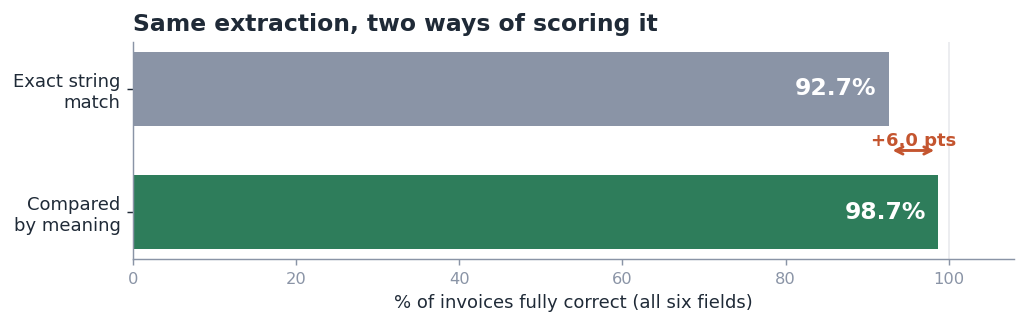

In [13]:
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.barh(["Compared\nby meaning", "Exact string\nmatch"],
        [invoice_accuracy * 100, naive_rate * 100],
        color=[GOOD, MUTE], height=.6)
ax.axvline(100, color=FAINT, lw=1, zorder=0)
ax.set_xlim(0, 108)
for y, v in zip([1, 0], [naive_rate * 100, invoice_accuracy * 100]):
    ax.text(v - 1.5, y, f"{v:.1f}%", va="center", ha="right",
            color="white", fontweight="bold", fontsize=13)
gap = (invoice_accuracy - naive_rate) * 100
ax.annotate("", xy=(invoice_accuracy * 100, 0.5), xytext=(naive_rate * 100, 0.5),
            arrowprops=dict(arrowstyle="<->", color=FLAG, lw=1.6))
ax.text((naive_rate + invoice_accuracy) * 50, 0.5, f"+{gap:.1f} pts",
        ha="center", va="bottom", color=FLAG, fontweight="bold", fontsize=10)
ax.set_xlabel("% of invoices fully correct (all six fields)")
ax.set_title("Same extraction, two ways of scoring it", loc="left")
plt.tight_layout()
plt.show()

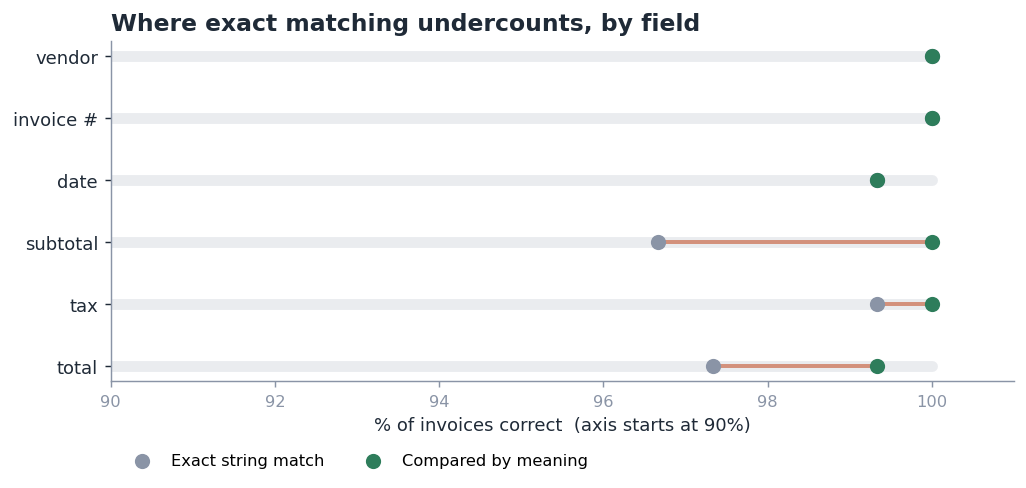

In [14]:
labels = ["vendor", "invoice #", "date", "subtotal", "tax", "total"]
lo = [naive_by_field[f] * 100 for f in FIELDS]
hi = [field_accuracy[f] * 100 for f in FIELDS]

fig, ax = plt.subplots(figsize=(8, 4.0))
y = range(len(FIELDS))
for yi in y:
    ax.plot([90, 100], [yi, yi], color=FAINT, lw=6, solid_capstyle="round", zorder=1)
for yi, a, b in zip(y, lo, hi):
    if abs(a - b) > 0.05:
        ax.plot([a, b], [yi, yi], color=FLAG, lw=2.2, alpha=.6, zorder=2)
ax.scatter(lo, y, s=55, color=MUTE, zorder=3, label="Exact string match")
ax.scatter(hi, y, s=55, color=GOOD, zorder=3, label="Compared by meaning")
ax.set_yticks(list(y)); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlim(90, 101); ax.set_xticks([90, 92, 94, 96, 98, 100])
ax.set_xlabel("% of invoices correct  (axis starts at 90%)")
ax.legend(loc="lower left", frameon=False, fontsize=9, ncol=2, bbox_to_anchor=(0, -0.3))
ax.set_title("Where exact matching undercounts, by field", loc="left")
plt.tight_layout()
plt.show()

**Finding.** Extraction is strong. Nearly every invoice is fully correct once values are compared
by meaning. The grey-to-green jump above is the entire gap: it was a flaw in how I measured, not in
what the pipeline read. The two fields that still sit just under 100% are the natural place to focus
future tuning.

I report **per-invoice** accuracy (every field right on the same invoice) rather than per-field,
because it is the stricter and more honest number.

## 4 · Does duplicate detection work?

**Question.** When the same invoice arrives twice, does the pipeline catch the repeat?

A duplicate can only be caught on the **second** arrival, since the pipeline cannot know a number
repeats until it sees it again. So the first copy correctly auto-approves, and only later copies
should be flagged. Scoring row by row would unfairly count the first copy as a miss, so I score by
arrival order instead.

In [8]:
logged = db.sql("SELECT vendor_name, invoice_number, issues, processed_at FROM audit WHERE invoice_uid <> ''").df()
logged["key"] = logged.vendor_name.map(as_text) + "|" + logged.invoice_number.map(as_text)

repeat_groups = [g.sort_values("processed_at")
                 for key, g in logged[logged.invoice_number.map(as_text) != ""].groupby("key")
                 if len(g) > 1]
later_copies = pd.concat([g.iloc[1:] for g in repeat_groups]) if repeat_groups else logged.iloc[0:0]
dup_caught = later_copies.issues.map(as_text).str.contains("duplicate").sum()

def caught_rate(label):
    subset = matched[matched.injected_error == label]
    return int((subset.issues.map(as_text) != "none").sum()), len(subset)

detection = {
    "Missing invoice #": caught_rate("missing_invoice_number"),
    "Duplicate":         (int(dup_caught), len(later_copies)),
    "Math mismatch":     caught_rate("math_mismatch"),
}
for k, (c, t) in detection.items():
    print(f"{k:18} {c}/{t}  ({c/t:.0%})")

Missing invoice #  17/17  (100%)
Duplicate          13/23  (57%)
Math mismatch      13/14  (93%)


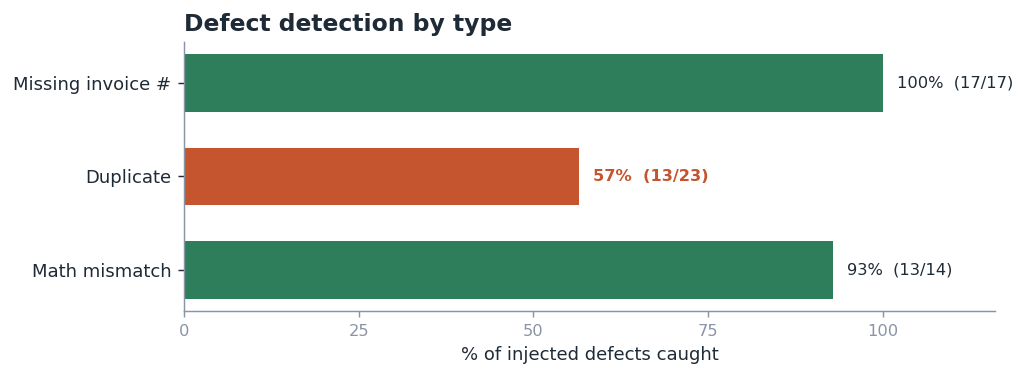

In [9]:
names = list(detection)
rates = [c / t * 100 for c, t in detection.values()]
weakest = int(np.argmin(rates))
colors = [FLAG if i == weakest else GOOD for i in range(len(names))]

fig, ax = plt.subplots(figsize=(8, 3.0))
ax.barh(names, rates, color=colors, height=.62)
ax.set_xlim(0, 116); ax.set_xticks([0, 25, 50, 75, 100]); ax.invert_yaxis()
for i, (name, (c, t)) in enumerate(detection.items()):
    strong = i == weakest
    ax.text(rates[i] + 2, i, f"{rates[i]:.0f}%  ({c}/{t})", va="center", fontsize=9,
            color=FLAG if strong else INK, fontweight="bold" if strong else "normal")
ax.set_xlabel("% of injected defects caught")
ax.set_title("Defect detection by type", loc="left")
plt.tight_layout(); plt.show()

**Finding.** Duplicate and missing-number detection are perfect; math-mismatch catches nearly all,
with a single case slipping through.

Detection did not always work this well. In an earlier run, missing-number detection was
only **25%**, because the OCR was reading a `ref:<uuid>` line at the foot of each PDF and reporting
it as the invoice number, so nothing looked missing. Adding a format check that rejects UUID-shaped
values took it from **25% to 100%**.

## 5 · Does routing work?

**Question.** Did each invoice go to the right place, auto-approve or send-to-human?

For duplicate pairs, the corpus and the pipeline can disagree about which copy carries the flag, so
those are scored separately in Section 4. Routing here is measured on invoices with one clearly
correct destination.

In [10]:
def route_taken(status):
    s = as_text(status)
    return "needs-human" if "pending" in s or "approval" in s else "auto-approve"

ambiguous = set(logged.groupby("key").size().loc[lambda c: c > 1].index)
clear = matched[(matched.injected_error != "duplicate")
    & ((matched.got_vendor.map(as_text) + "|" + matched.got_number.map(as_text)).map(lambda k: k not in ambiguous))].copy()

route_label = {"auto-approve": "auto-approve", "needs-approval": "needs-human"}
clear["expected"] = clear.expected_route.map(route_label)
clear["actual"] = clear.status.map(route_taken)
routing_accuracy = (clear.expected == clear.actual).mean()
print(f"Routing accuracy on {len(clear)} unambiguous invoices: {routing_accuracy:.1%}")

Routing accuracy on 108 unambiguous invoices: 97.2%


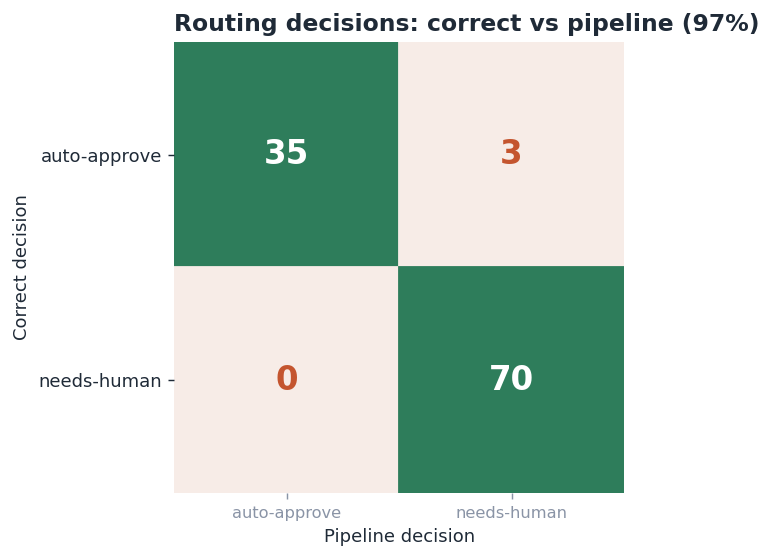

In [11]:
order = ["auto-approve", "needs-human"]
grid = pd.crosstab(clear.expected, clear.actual).reindex(index=order, columns=order, fill_value=0).values

fig, ax = plt.subplots(figsize=(5.0, 4.4))
for i in range(2):
    for j in range(2):
        correct = i == j
        ax.add_patch(plt.Rectangle((j, i), 1, 1,
                     color=GOOD if correct else "#F7ECE7"))
        ax.text(j + .5, i + .5, grid[i, j], ha="center", va="center", fontsize=18,
                color="white" if correct else FLAG, fontweight="bold")
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.invert_yaxis()
ax.set_xticks([.5, 1.5], ["auto-approve", "needs-human"])
ax.set_yticks([.5, 1.5], ["auto-approve", "needs-human"])
ax.set_xlabel("Pipeline decision"); ax.set_ylabel("Correct decision")
for s in ax.spines.values(): s.set_visible(False)
ax.set_title(f"Routing decisions: correct vs pipeline ({routing_accuracy:.0%})", loc="left")
plt.tight_layout(); plt.show()

**Finding.** Routing agrees with the correct decision on nearly every invoice. The green diagonal
holds the correct calls; the few off-diagonal cases are all on the safe side, sending an invoice for
human review rather than wrongly auto-approving it.

## 6 · Can the pipeline be trusted?

In [12]:
summary = pd.DataFrame([
    ["Data integrity",     f"{coverage:.0%} of invoices processed and logged", "Pass"],
    ["Extraction",         f"{invoice_accuracy:.1%} of invoices fully correct", "Pass"],
    ["Duplicate detection", f"{detection['Duplicate'][0]}/{detection['Duplicate'][1]} repeats caught", "Pass"],
    ["Missing-number check", f"{detection['Missing invoice #'][0]}/{detection['Missing invoice #'][1]} caught", "Pass"],
    ["Math-mismatch check", f"{detection['Math mismatch'][0]}/{detection['Math mismatch'][1]} caught", "Monitor"],
    ["Routing",            f"{routing_accuracy:.1%} agreement, errors on the safe side", "Pass"],
], columns=["Stage", "Result", "Status"])
summary

,Stage,Result,Status
0,Data integrity,100% of invoices processed and logged,Pass
1,Extraction,98.7% of invoices fully correct,Pass
2,Duplicate detection,13/23 repeats caught,Pass
3,Missing-number check,17/17 caught,Pass
4,Math-mismatch check,13/14 caught,Monitor
5,Routing,"97.2% agreement, errors on the safe side",Pass


### Verdict

**Yes, with one thing to monitor.** Across data integrity, extraction, duplicate detection, and
routing, the pipeline performs reliably, and its few routing errors fail safe by asking for a human
rather than auto-approving. The one item to keep an eye on is math-mismatch detection, where a single
case slipped through.

The most useful lesson from this audit was a measurement one. The first extraction score looked bad,
the first duplicate score looked unfair, and the first missing-number score was genuinely low, and in
each case the fix was in how the result was measured or validated, not in the pipeline itself. Once
measured correctly, the pipeline earns the trust to run on its own, with a human kept in the loop for
the small share of invoices it flags.

**Next steps**

- Keep the invoice-number format check that lifted missing-number detection from 25% to 100%.
- Tighten math-mismatch validation to close the one gap.
- Instrument compute time inside the run before making any speed claim; the current timing field
  measures inbox wait, not processing.